# **Library**

In [1]:
import numpy as np
import pandas as pd

from google.colab import files
files.upload()

df = pd.read_csv("StudentPerformance.csv")

Saving StudentPerformance.csv to StudentPerformance.csv


# **Data Processing**

In [2]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [4]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [5]:
df['Extracurricular Activities'] = (df['Extracurricular Activities'] == 'Yes').astype(int)

X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

# **Data Visualization**

[]

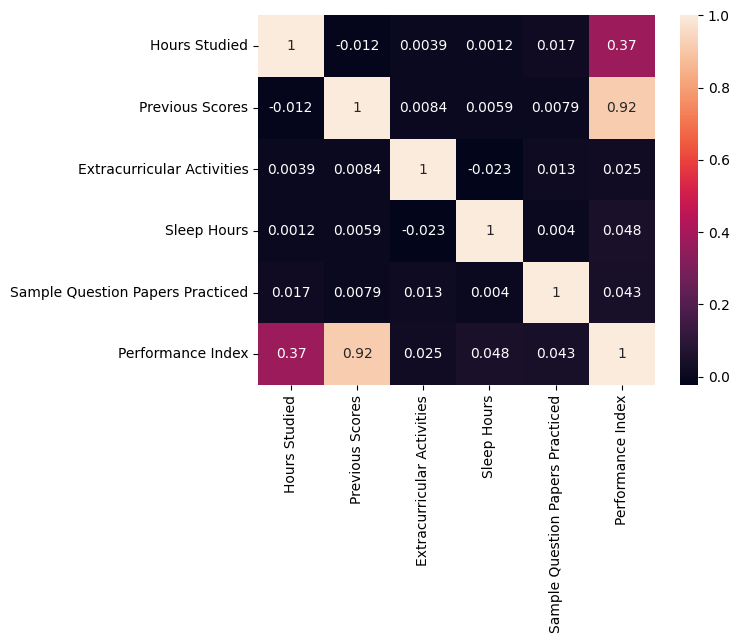

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.plot()

In [7]:
df.groupby("Performance Index")['Previous Scores'].mean()

,Previous Scores
Performance Index,
10.0,40.000000
11.0,40.400000
12.0,40.875000
13.0,40.769231
14.0,40.857143
...,...
96.0,98.357143
97.0,98.000000
98.0,98.285714


# **Simple Linear Regression**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Previous Scores']]
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

LinearRegression()

In [10]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred = simple_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE:{rmse:.2f}')
print(f'r2:{r2:.2f}')

RMSE:7.68
r2:0.84


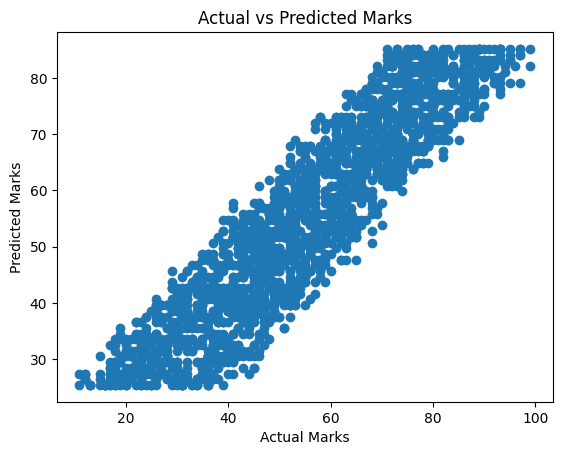

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()


In [12]:
simple_model.predict([[50]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([35.531925])

# **Multiple Linear Regression**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

LinearRegression()

In [15]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred = simple_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE:{rmse:.2f}')
print(f'r2:{r2:.2f}')

RMSE:2.02
r2:0.99


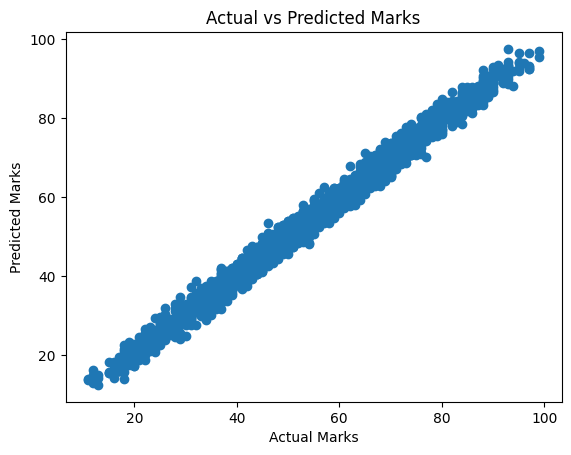

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()


In [18]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [20]:
simple_model.predict([[5,	69,	0,	9,	1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([54.99696396])